In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import KNNImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [2]:
bd = pd.read_csv('../Datos/metadata.csv')

# Agrupamos en una columna patient_id y leion_id
bd['patient_lesion_id'] = bd['patient_id'].astype(str) + '_' + bd['lesion_id'].astype(str)

# 1) Agrupar imágenes por lesión (1 fila por patient_lesion_id)
df_img = (bd.groupby("patient_lesion_id", as_index=False)["img_id"]
            .agg(lambda x: ", ".join(x.astype(str))))

# 2) Datos clínicos: eliminar SOLO duplicados 100 % idénticos
Train_raw = bd.drop(columns=["img_id"]).copy()

total_duplicados = Train_raw.duplicated().sum()
print(f"Duplicados 100% idénticos: {total_duplicados}")

Train_raw = Train_raw.drop_duplicates(keep="first")

# 3) Unir
df_agrupado = Train_raw.merge(df_img, on="patient_lesion_id", how="left")

display(df_agrupado.head())

# Volver a comprobar duplicados
total_duplicados = df_agrupado.duplicated().sum()
print(f"Duplicados 100% idénticos tras agrupar: {total_duplicados}")

Duplicados 100% idénticos: 94


,patient_id,lesion_id,smoke,drink,background_father,background_mother,age,pesticide,gender,skin_cancer_history,...,itch,grew,hurt,changed,bleed,elevation,biopsed,diagnostic,patient_lesion_id,img_id
0,PAT_715,4072,False,True,POMERANIA,POMERANIA,80,True,MALE,False,...,FALSE,FALSE,FALSE,FALSE,FALSE,TRUE,False,ACK,PAT_715_4072,PAT_715_4072_827.png
1,PAT_217,963,False,True,POMERANIA,POMERANIA,76,False,MALE,False,...,TRUE,FALSE,FALSE,FALSE,TRUE,FALSE,False,ACK,PAT_217_963,PAT_217_963_806.png
2,PAT_86,1082,False,False,POMERANIA,POMERANIA,53,False,FEMALE,True,...,TRUE,TRUE,TRUE,FALSE,TRUE,TRUE,True,ACK,PAT_86_1082,"PAT_86_1082_41.png, PAT_86_1082_220.png"
3,PAT_880,1675,False,False,GERMANY,GERMANY,83,False,FEMALE,True,...,TRUE,FALSE,TRUE,FALSE,FALSE,FALSE,True,ACK,PAT_880_1675,PAT_880_1675_704.png
4,PAT_645,4042,False,False,GERMANY,GERMANY,57,True,FEMALE,True,...,TRUE,TRUE,FALSE,FALSE,FALSE,TRUE,False,ACK,PAT_645_4042,PAT_645_4042_489.png


Duplicados 100% idénticos tras agrupar: 0


In [3]:
Train_raw, Test_raw = train_test_split(df_agrupado, test_size=0.2, random_state=42, stratify=df_agrupado['diagnostic'])

Train_raw.to_csv('../Datos/Train_raw.csv', index=False)
Test_raw.to_csv('../Datos/Test_raw.csv', index=False)

### Preprocessing de NaNs

Vemos que columnas tienen NaN

In [4]:
NaN = pd.DataFrame({"Count":Train_raw.isnull().sum(),"Porcentaje":round(Train_raw.isnull().sum()/len(Train_raw)*100,2)})
NaN = NaN.sort_values(by="Count", ascending=False)
NaN = NaN[NaN["Count"]>0]
display(NaN)

,Count,Porcentaje
background_father,136,24.03
background_mother,136,24.03
smoke,131,23.14
skin_cancer_history,131,23.14
gender,131,23.14
drink,131,23.14
pesticide,131,23.14
cancer_history,131,23.14
fitspatrick,131,23.14
has_sewage_system,131,23.14


Para las columnas booleanas vamos a cambiar los NaN, por una variable llamada (Unknown)

In [5]:
cols_para_fix = ['smoke', 'drink','pesticide','gender','skin_cancer_history','cancer_history','has_piped_water','has_sewage_system']
Train_raw[cols_para_fix] = Train_raw[cols_para_fix].fillna('Unknown')

Vamos a ver como se distribuyen las columnas con valor discreto (background_father, background_mother y fitspatrick)

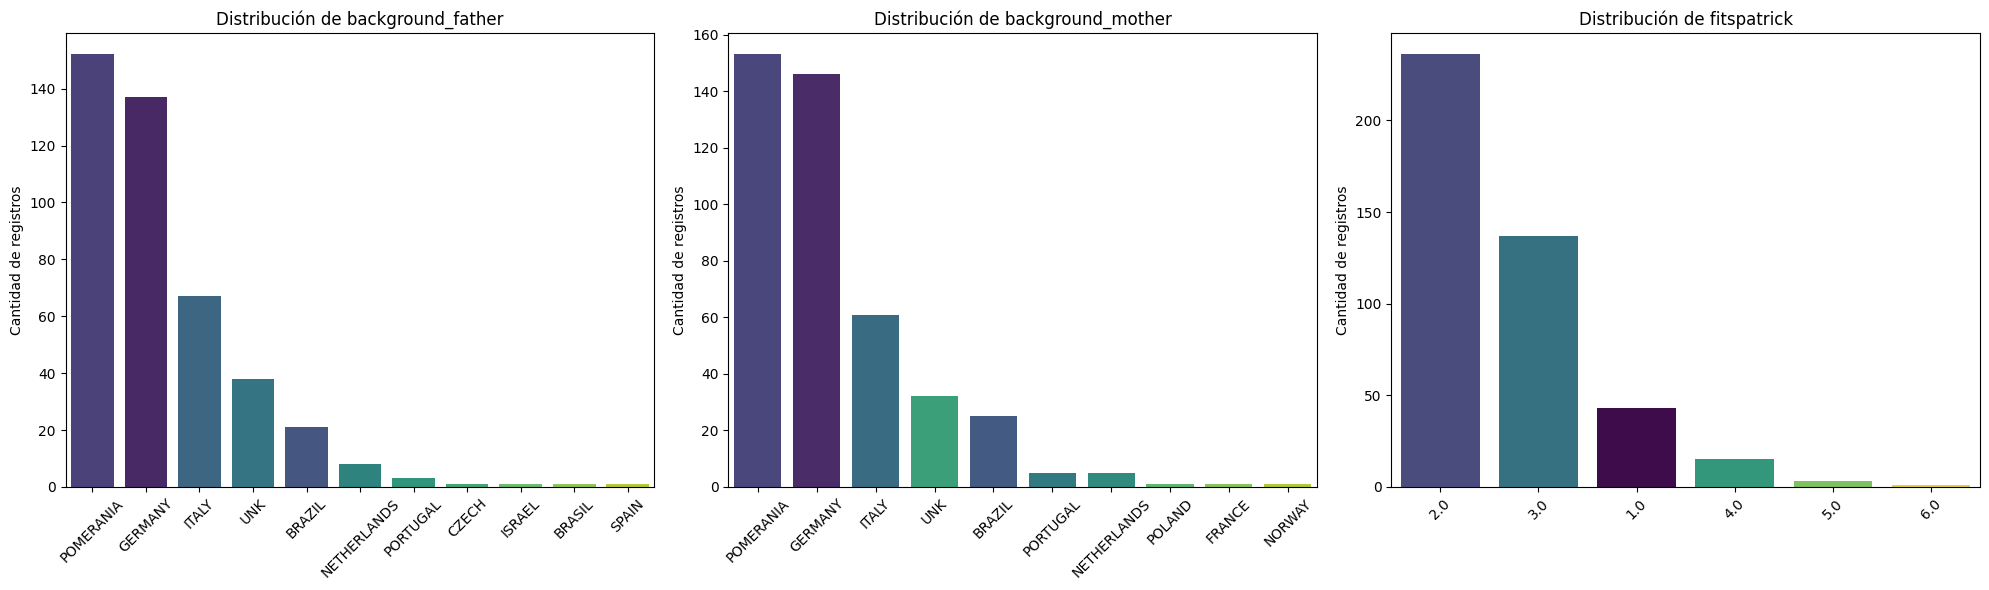

In [6]:
cols_discretas = ['background_father', 'background_mother', 'fitspatrick']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, col in enumerate(cols_discretas):
    # Ordenamos los datos para el eje X
    order = Train_raw[col].value_counts().index
    
    sns.countplot(
        data=Train_raw, 
        x=col, 
        ax=axes[i], 
        hue=col, 
        palette='viridis', 
        order=order, 
        legend=False
    )
    
    axes[i].set_title(f'Distribución de {col}')
    
    axes[i].tick_params(axis='x', rotation=45)
    
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Cantidad de registros')

plt.tight_layout()
plt.show()

Vamos a rellenar los NaN en función de los porcentajes que se observan en los histogramas, esto quiere decir que por ejemplo, si en a columna fitspatrick hay un 55% de que el NaN se sustituya por "2.0" se utilizará ese porcentaje.

In [7]:
# Para que los resultados sean siempre los mismos al ejecutar
np.random.seed(42) 

for col in cols_discretas:
    # 1. Calculamos la distribución ignorando los NaNs
    # value_counts() por defecto no cuenta los nulos
    counts = Train_raw[col].value_counts(normalize=True)
    categorias = counts.index
    probabilidades = counts.values
    
    # 2. Identificamos qué filas tienen el valor nulo (NaN)
    mask_nulos = Train_raw[col].isnull()
    cantidad_a_rellenar = mask_nulos.sum()
    
    # 3. Si hay nulos, rellenamos con el "sorteo" basado en los porcentajes
    if cantidad_a_rellenar > 0:
        valores_imputados = np.random.choice(
            categorias, 
            size=cantidad_a_rellenar, 
            p=probabilidades
        )
        
        # 4. Sustituimos los NaN por los valores sorteados
        Train_raw.loc[mask_nulos, col] = valores_imputados

Ahora solo quedan dos columnas con NaNs, diameter_1 y diameter_2. Estas tienen valores continuas, así que vamos a observar sus distribuciones

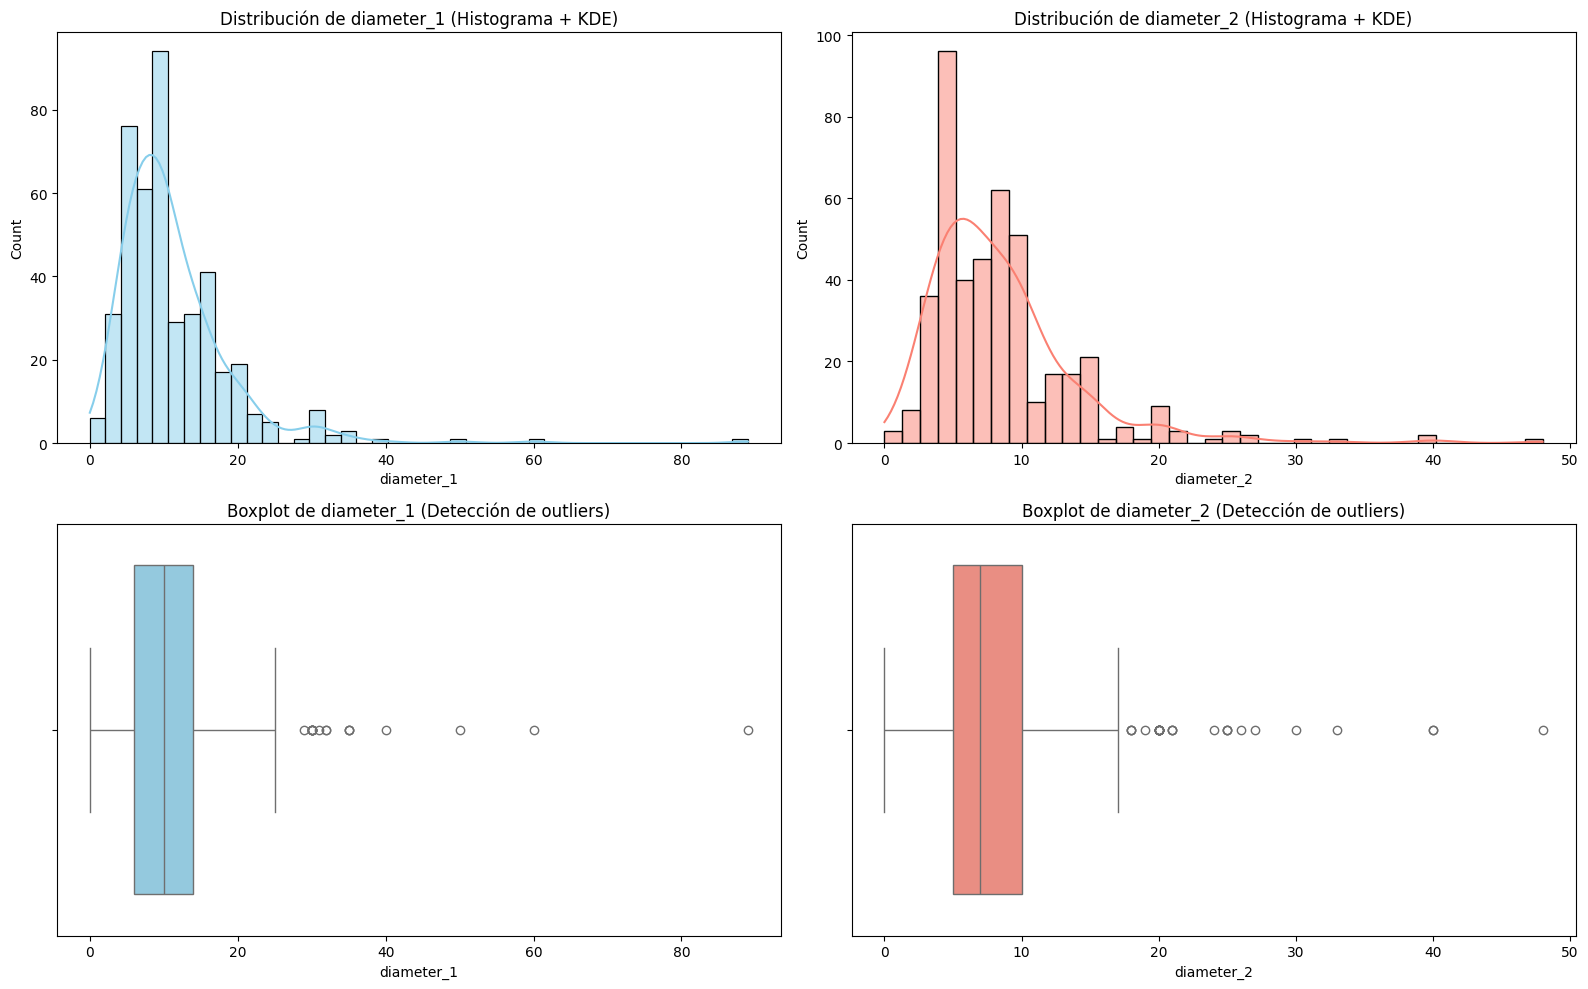

,diameter_1,diameter_2
count,435.000000,435.000000
mean,11.301149,8.526437
std,7.941252,5.602922
min,0.000000,0.000000
25%,6.000000,5.000000
50%,10.000000,7.000000
75%,14.000000,10.000000
max,89.000000,48.000000


In [8]:
# Configuramos el lienzo para 4 gráficos (2 por columna)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# --- Análisis de diameter_1 ---
sns.histplot(Train_raw['diameter_1'].dropna(), kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Distribución de diameter_1 (Histograma + KDE)')

sns.boxplot(x=Train_raw['diameter_1'], ax=axes[1, 0], color='skyblue')
axes[1, 0].set_title('Boxplot de diameter_1 (Detección de outliers)')

# --- Análisis de diameter_2 ---
sns.histplot(Train_raw['diameter_2'].dropna(), kde=True, ax=axes[0, 1], color='salmon')
axes[0, 1].set_title('Distribución de diameter_2 (Histograma + KDE)')

sns.boxplot(x=Train_raw['diameter_2'], ax=axes[1, 1], color='salmon')
axes[1, 1].set_title('Boxplot de diameter_2 (Detección de outliers)')

plt.tight_layout()
plt.show()

# Estadisticas
display(Train_raw[['diameter_1', 'diameter_2']].describe())

Para completar los NaNs, vamos a utilizar imputación KNN, la cual permite rellenar los huecos basándose en el perfil de pacientes con características similares en lugar de usar una media o mediana. Esto último se descarta debido a que estos métodos asignan un valor idéntico a todos los registros, ignorando las particularidades de cada caso y reduciendo artificialmente la variabilidad de los datos. Esto tiene sentido, ya que el tamaño de una lesión no es un evento aleatorio, sino que suele estar condicionado por otros factores, como los que tenemos como columnas. Al emplear este método, se logra preservar la distribución original de la muestra, manteniendo la proporción real entre lesiones pequeñas y grandes sin distorsionar los datos. Asimismo, este procedimiento permite gestionar adecuadamente los outliers, asegurando que estos registros médicos tan relevantes no se pierdan, pero evitando a la vez que su valor extremo afecte artificialmente al resto de las estimaciones, garantizando así un dataset final mucho más preciso y cercano a la realidad clínica.

In [9]:
df_knn = Train_raw.copy()

# 1) Detectar categóricas (incluye category y bool)
categorical_cols = df_knn.select_dtypes(include=["object", "bool", "category"]).columns

# 2) Quitar/gestionar datetimes (si existen)
datetime_cols = df_knn.select_dtypes(include=["datetime64[ns]", "timedelta64[ns]"]).columns
df_knn = df_knn.drop(columns=datetime_cols)

# 3) Mantener missing (NO usar astype(str))
for col in categorical_cols:
    df_knn[col] = df_knn[col].astype("string")

encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1,
    encoded_missing_value=np.nan
)

df_knn[categorical_cols] = encoder.fit_transform(df_knn[categorical_cols])

# 4) Imputación KNN
imputer = KNNImputer(n_neighbors=5)
df_imputed = pd.DataFrame(imputer.fit_transform(df_knn), columns=df_knn.columns, index=df_knn.index)

# 5) Volcar columnas de interés
Train_raw["diameter_1"] = df_imputed["diameter_1"]
Train_raw["diameter_2"] = df_imputed["diameter_2"]

## 2- Data Encoding

### Convertir a valor numérico las columnas con One_Hot Encoding

Para transformar los datos de texto a números, se ha utilizado One-Hot Encoding en lugar de asignar números seguidos (1, 2, 3...) porque la mayoría de las categorías no tienen un orden lógico. Si asignáramos números correlativos a variables como el sexo o el país de origen, el modelo podría pensar erróneamente que una opción es "más importante" o "vale más" que otra solo por tener un número más alto. Al crear columnas independientes de ceros y unos, nos aseguramos de que el modelo trate cada característica de forma justa y separada, evitando errores de interpretación y respetando la realidad de los datos médicos.

In [10]:
# 1. Identificamos las columnas categóricas
cols_categoricas = Train_raw.select_dtypes(include=['object', 'bool']).columns.tolist()

# Quitamos las columnas que NO queremos transformar
col_no_categorias = ['patient_id', 'img_id', 'lesion_id', 'patient_lesion_id','diagnostic']

for col in col_no_categorias:
    if col in cols_categoricas:
        cols_categoricas.remove(col)

# Aplicamos One-Hot Encoding solo a las demás columnas
Train_encoded = pd.get_dummies(
    Train_raw, 
    columns=cols_categoricas, 
    prefix_sep='_', 
    dtype=int
)

### Convertimos la columna que será el target (diagnostic) a número sin One-Hot Encoding

In [11]:
# 1. Creamos el codificador
le = LabelEncoder()

# 2. Aplicamos la transformación a la columna diagnostic
# Lo hacemos sobre el DataFrame 'Train_encoded' que ya tiene el resto procesado
Train_encoded['diagnostic'] = le.fit_transform(Train_encoded['diagnostic'])

# 3. Creamos un diccionario para ver la correspondencia
mapeo_diagnostico = dict(zip(le.classes_, le.transform(le.classes_)))

print("--- Mapeo de Diagnósticos ---")
for nombre, numero in mapeo_diagnostico.items():
    print(f"Número {numero}: {nombre}")

--- Mapeo de Diagnósticos ---
Número 0: ACK
Número 1: BCC
Número 2: MEL
Número 3: NEV
Número 4: SCC
Número 5: SEK


## 3- Anexamos la columna `img_id` y agregamos una columna de diagnostico (Benigno y Maligno)

In [12]:
# Creamos un diccionario de mapeo
mapping = {
    0: 0,  # ACK -> Benigno 
    1: 1,  # BCC -> Maligno
    2: 1,  # MEL -> Maligno
    3: 0,  # NEV -> Benigno
    4: 1,  # SCC -> Maligno
    5: 0   # SEK -> Benigno
}

# Creamos la nueva columna
Train_clean = Train_encoded.copy()

Train_clean['diagnostic_binario'] = Train_clean['diagnostic'].map(mapping)

# Verificamos el conteo de la nueva distribución
print(Train_clean['diagnostic_binario'].value_counts())

Train_clean.to_csv('../Datos/Train_clean.csv', index=False)

diagnostic_binario
0    324
1    242
Name: count, dtype: int64


Limpiar ahora el test_raw igual que el train_raw

In [13]:
## Imputación en Test para columnas bool
cols_para_fix = ['smoke', 'drink','pesticide','gender','skin_cancer_history','cancer_history','has_piped_water','has_sewage_system']
Test_raw[cols_para_fix] = Test_raw[cols_para_fix].fillna('Unknown')


## Imputación de variables discretas en Test usando distribución del Train
cols_discretas = ['background_father', 'background_mother', 'fitspatrick']

# Para reproducibilidad (puedes usar otra semilla si quieres)
np.random.seed(42)

for col in cols_discretas:
    # 1) Distribución aprendida SOLO del train (ignorando NaN)
    train_counts = Train_raw[col].value_counts(normalize=True, dropna=True)
    categorias = train_counts.index.to_numpy()
    probabilidades = train_counts.values

    # 2) Filas nulas en test
    mask_nulos_test = Test_raw[col].isnull()
    cantidad_a_rellenar = int(mask_nulos_test.sum())

    # 3) Relleno en test usando probabilidades del train
    if cantidad_a_rellenar > 0:
        # Si por lo que sea el train no tiene categorías (columna todo NaN),
        # no podemos muestrear: lo dejamos en NaN o pon un valor fijo.
        if len(categorias) == 0:
            # opción: dejar NaN
            continue

        valores_imputados = np.random.choice(
            categorias,
            size=cantidad_a_rellenar,
            p=probabilidades
        )

        Test_raw.loc[mask_nulos_test, col] = valores_imputados

## Imputación KNN en Test usando parámetros del Train
df_knn_test = Test_raw.copy()

# 2) Quitar/gestionar datetimes (si existen)
datetime_cols_test = df_knn_test.select_dtypes(include=["datetime64[ns]", "timedelta64[ns]"]).columns
df_knn_test = df_knn_test.drop(columns=datetime_cols_test)

# Asegurar mismas columnas/orden que en train (df_knn)
df_knn_test = df_knn_test.reindex(columns=df_knn.columns)

# 1) Detectar categóricas (usa las mismas del train)
for col in categorical_cols:
    df_knn_test[col] = df_knn_test[col].astype("string")

df_knn_test[categorical_cols] = encoder.transform(df_knn_test[categorical_cols])

df_imputed_test = pd.DataFrame(
    imputer.transform(df_knn_test),
    columns=df_knn_test.columns,
    index=df_knn_test.index
)

Test_raw["diameter_1"] = df_imputed_test["diameter_1"]
Test_raw["diameter_2"] = df_imputed_test["diameter_2"]


Encoding y guuardar

In [14]:
# 1. Identificamos las columnas categóricas
cols_categoricas = Test_raw.select_dtypes(include=['object', 'bool']).columns.tolist()

# Quitamos las columnas que NO queremos transformar
col_no_categorias = ['patient_id', 'img_id', 'lesion_id', 'patient_lesion_id','diagnostic']

for col in col_no_categorias:
    if col in cols_categoricas:
        cols_categoricas.remove(col)

# Aplicamos One-Hot Encoding solo a las demás columnas
Test_encoded = pd.get_dummies(Test_raw,columns=cols_categoricas,prefix_sep='_',dtype=int)
Test_encoded = Test_encoded.reindex(columns=Train_encoded.columns, fill_value=0)
# Aplicamos la transformación a la columna diagnostic

Test_encoded['diagnostic'] = le.transform(Test_encoded['diagnostic'])

# 3. Creamos un diccionario para ver la correspondencia
mapeo_diagnostico = dict(zip(le.classes_, le.transform(le.classes_)))

print("--- Mapeo de Diagnósticos ---")
for nombre, numero in mapeo_diagnostico.items():
    print(f"Número {numero}: {nombre}")
# Creamos un diccionario de mapeo
mapping = {
    0: 0,  # ACK -> Benigno 
    1: 1,  # BCC -> Maligno
    2: 1,  # MEL -> Maligno
    3: 0,  # NEV -> Benigno
    4: 1,  # SCC -> Maligno
    5: 0   # SEK -> Benigno
}

# Creamos la nueva columna
Test_clean = Test_encoded.copy()

Test_clean['diagnostic_binario'] = Test_clean['diagnostic'].map(mapping)

# Verificamos el conteo de la nueva distribución
print(Test_clean['diagnostic_binario'].value_counts())

Test_clean.to_csv('../Datos/Test_clean.csv', index=False)

--- Mapeo de Diagnósticos ---
Número 0: ACK
Número 1: BCC
Número 2: MEL
Número 3: NEV
Número 4: SCC
Número 5: SEK
diagnostic_binario
0    81
1    61
Name: count, dtype: int64
